In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
K_REFINED = 1 # None = all refinements; set e.g. 1 to truncate Bayesian after k-th refinement

In [3]:
LBFGS_SWEEP = 'convergence_w5'
BAYESIAN_SWEEP = 'convergence_w5_bayesian/04_18'

In [4]:
BASE = '../examples/comparisons/combined_boundary_DIIID'

def load_run(run_dir):
    """Load results.json if present, else checkpoint.json. Returns flat dict."""
    results_path = os.path.join(run_dir, 'results.json')
    ckpt_path = os.path.join(run_dir, 'checkpoint.json')
    if os.path.exists(results_path):
        with open(results_path) as f:
            raw = json.load(f)
        s = raw['optimization_settings']
        method_name = list(raw['methods'].keys())[0]
        d = raw['methods'][method_name]
        d['optimization_settings'] = s
        d['method'] = method_name
        d['source'] = 'results'
        return d
    elif os.path.exists(ckpt_path):
        with open(ckpt_path) as f:
            d = json.load(f)
        d['source'] = 'checkpoint'
        return d
    return None

def discover_runs(base):
    runs = []
    for sweep in sorted(os.listdir(base)):
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            continue
        for config in sorted(os.listdir(sweep_dir)):
            config_dir = os.path.join(sweep_dir, config)
            if not os.path.isdir(config_dir):
                continue
            for run in sorted(os.listdir(config_dir)):
                run_dir = os.path.join(config_dir, run)
                if not os.path.isdir(run_dir):
                    continue
                d = load_run(run_dir)
                if d is None:
                    continue
                s = d.get('optimization_settings', {})
                runs.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'run_dir': run_dir,
                    'source': d['source'],
                    'method': d.get('method', '?'),
                    'weight_fb': s.get('weight_fb', float('nan')),
                    'alpha': s.get('alpha', float('nan')),
                    'num_coils': s.get('num_coils', '?'),
                    'n_evals': d.get('n_evals', float('nan')),
                    'best_cost': d.get('best_cost', float('nan')),
                    'best_flux_err': d.get('best_flux_err', float('nan')),
                    'best_fb_cost': d.get('best_fb_cost', float('nan')),
                    'fb_failures': d.get('fb_failures', float('nan')),
                    'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                    'stopping': d.get('stopping', '?'),
                    'data': d,
                })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['config']}/{r['run']}  [{r['source']}]  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

4 runs found
  convergence_w5/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-01  best=2.7648e-01  evals=1239  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-02  best=1.3188e-01  evals=1239  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-03,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-03  best=9.9891e-02  evals=1218  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-04,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-04  best=3.3780e-01  evals=1245  stop=in_progress


In [5]:
def discover_runs(base):
    runs = []
    for sweep in [LBFGS_SWEEP, BAYESIAN_SWEEP]:
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            print(f"not found: {sweep_dir}")
            continue
        for config in sorted(os.listdir(sweep_dir)):
            config_dir = os.path.join(sweep_dir, config)
            if not os.path.isdir(config_dir):
                continue
            for run in sorted(os.listdir(config_dir)):
                run_dir = os.path.join(config_dir, run)
                if not os.path.isdir(run_dir):
                    continue
                d = load_run(run_dir)
                if d is None:
                    continue
                s = d.get('optimization_settings', {})
                runs.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'run_dir': run_dir,
                    'source': d['source'],
                    'method': d.get('method', '?'),
                    'weight_fb': s.get('weight_fb', float('nan')),
                    'alpha': s.get('alpha', float('nan')),
                    'num_coils': s.get('num_coils', '?'),
                    'n_evals': d.get('n_evals', float('nan')),
                    'best_cost': d.get('best_cost', float('nan')),
                    'best_flux_err': d.get('best_flux_err', float('nan')),
                    'best_fb_cost': d.get('best_fb_cost', float('nan')),
                    'fb_failures': d.get('fb_failures', float('nan')),
                    'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                    'stopping': d.get('stopping', '?'),
                    'data': d,
                })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['config']}/{r['run']}  [{r['source']}]  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

8 runs found
  convergence_w5/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-01  best=2.7648e-01  evals=1239  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-02  best=1.3188e-01  evals=1239  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-03,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-03  best=9.9891e-02  evals=1218  stop=in_progress
  convergence_w5/alpha:0.75,weight:1e-04,lambda:1e-06,coils:3/run_01  [checkpoint]  method=L-BFGS  weight_fb=1e-04  best=3.3780e-01  evals=1245  stop=in_progress
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-01  best=9.4196e-01  evals=574  stop=all refinements completed
  convergence_w5_bayesian/04_18/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  [results]  method=Bayesian  weight_fb=1e-02  best=6.4825e-01  eva

In [6]:
rows = []
for r in runs:
    d = r['data']
    alpha = d.get('optimization_settings', {}).get('alpha', 0.75)

    total = np.array(d['cost_history'], dtype=float)
    flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
    fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

    if r['method'] == 'Bayesian' and K_REFINED is not None:
        n_bay = d.get('n_bayesian_evals', 0)
        ref_evals = d.get('refinement_evals', [])
        trunc = n_bay + sum(ref_evals[:min(K_REFINED, len(ref_evals))])
        total, flux, fb = total[:trunc], flux[:trunc], fb[:trunc]

    rows.append({
        'sweep': r['sweep'],
        'method': r['method'],
        'weight_fb': r['weight_fb'],
        'num_coils': r['num_coils'],
        'source': r['source'],
        'alpha': alpha,
        'best_cost_stored': float(np.nanmin(total)),
        'best_flux_err': float(np.nanmin(flux)),
        'best_fb_cost': float(np.nanmin(fb)),
        'init_fixed': d.get('initial_fixed_cost') or float('nan'),
        'init_fb': d.get('initial_fb_cost') or float('nan'),
        'fb_failures': r['fb_failures'],
        'n_evals': len(total),
        'elapsed_h': r['elapsed'] / 3600,
        'stopping': r['stopping'],
    })

df = pd.DataFrame(rows)

shared_norm_fixed = df['init_fixed'].max()
shared_norm_fb = df['init_fb'].max()
print(f"shared_norm_fixed={shared_norm_fixed:.4e}  shared_norm_fb={shared_norm_fb:.4e}")

df['best_cost_shared'] = (
    (1 - df['alpha']) * df['best_flux_err'] / shared_norm_fixed +
    df['alpha'] * df['best_fb_cost'] / shared_norm_fb
)

df = df.sort_values(['sweep', 'weight_fb'])
pd.set_option('display.float_format', '{:.4e}'.format)
df

shared_norm_fixed=2.0760e-01  shared_norm_fb=9.5215e+00


,sweep,method,weight_fb,num_coils,source,alpha,best_cost_stored,best_flux_err,best_fb_cost,init_fixed,init_fb,fb_failures,n_evals,elapsed_h,stopping,best_cost_shared
3,convergence_w5,L-BFGS,1.0000e-04,3,checkpoint,7.5000e-01,3.3780e-01,1.5334e-02,3.0418e+00,2.0760e-01,9.5215e+00,78,1245,1.9016e+01,in_progress,2.5807e-01
2,convergence_w5,L-BFGS,1.0000e-03,3,checkpoint,7.5000e-01,9.9891e-02,8.8538e-03,1.1225e+00,2.0760e-01,9.4351e+00,35,1218,1.9046e+01,in_progress,9.9082e-02
1,convergence_w5,L-BFGS,1.0000e-02,3,checkpoint,7.5000e-01,1.3188e-01,1.7657e-02,1.1371e+00,2.0760e-01,8.2582e+00,55,1239,1.9020e+01,in_progress,1.1084e-01
0,convergence_w5,L-BFGS,1.0000e-01,3,checkpoint,7.5000e-01,2.7648e-01,1.2386e-02,3.2196e+00,2.0760e-01,9.2317e+00,44,1239,1.9045e+01,in_progress,2.6852e-01
7,convergence_w5_bayesian/04_18,Bayesian,1.0000e-04,3,results,7.5000e-01,1.0000e+00,9.9392e-03,6.0453e-01,1.3629e-02,7.2958e-01,198,294,1.4248e+01,all refinements completed,5.9588e-02
6,convergence_w5_bayesian/04_18,Bayesian,1.0000e-03,3,results,7.5000e-01,1.0000e+00,1.2071e-02,6.0504e-01,1.3629e-02,7.2938e-01,3,238,9.9724e+00,all refinements completed,6.2195e-02
5,convergence_w5_bayesian/04_18,Bayesian,1.0000e-02,3,results,7.5000e-01,6.4825e-01,5.8378e-03,5.2134e-01,1.3629e-02,7.2253e-01,65,77,1.9501e+01,all refinements completed,4.8096e-02
4,convergence_w5_bayesian/04_18,Bayesian,1.0000e-01,3,results,7.5000e-01,9.4196e-01,9.1080e-03,1.8038e+00,1.3629e-02,2.0070e+00,3,168,8.5453e+00,all refinements completed,1.5305e-01


In [7]:
corrected_elapsed = []
for r in runs:
    d = r['data']
    if r['method'] == 'Bayesian' and K_REFINED is not None:
        t_bay = d.get('time_bayesian_phase', float('nan'))
        ref_times = d.get('refinement_times', [])
        elapsed = t_bay + sum(ref_times[:min(K_REFINED, len(ref_times))])
    else:
        elapsed = r['elapsed']
    corrected_elapsed.append(elapsed / 3600)

df['elapsed_h'] = corrected_elapsed

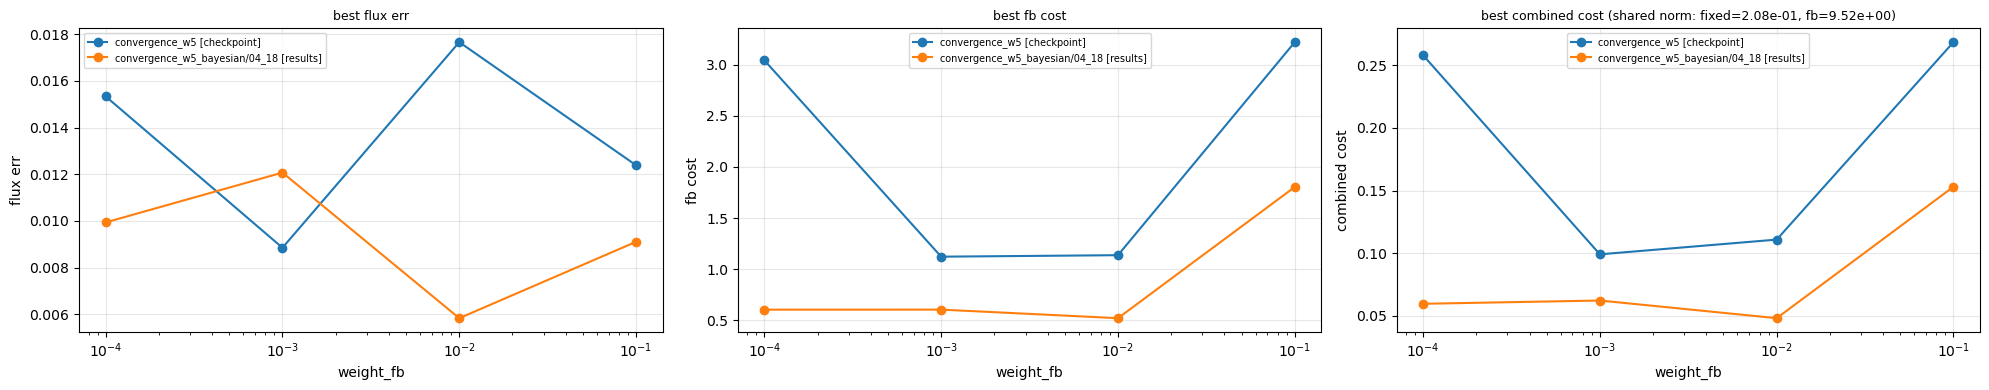

In [8]:
sweeps = df['sweep'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

for sweep in sweeps:
    sub = df[df['sweep'] == sweep].sort_values('weight_fb')
    label = f"{sweep} [{sub['source'].iloc[0]}]"
    axes[0].plot(sub['weight_fb'], sub['best_flux_err'], marker='o', label=label)
    axes[1].plot(sub['weight_fb'], sub['best_fb_cost'], marker='o', label=label)
    axes[2].plot(sub['weight_fb'], sub['best_cost_shared'], marker='o', label=label)

for ax, title, ylabel in zip(
    axes,
    ['best flux err', 'best fb cost', f'best combined cost (shared norm: fixed={shared_norm_fixed:.2e}, fb={shared_norm_fb:.2e})'],
    ['flux err', 'fb cost', 'combined cost']
):
    ax.set_xscale('log')
    ax.set_xlabel('weight_fb')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

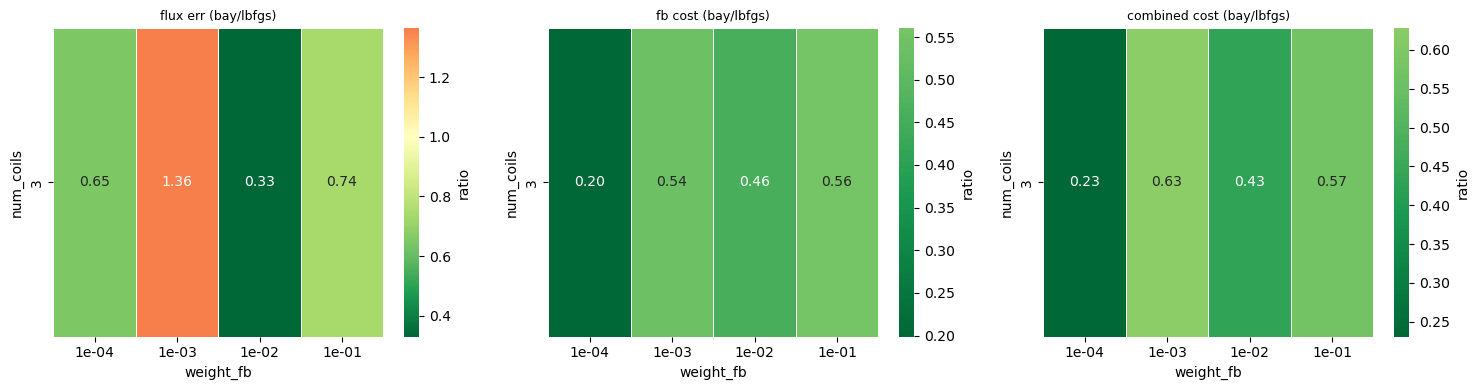

In [9]:
import seaborn as sns

bay = df[df['sweep'].str.contains('bayesian')].set_index(['num_coils', 'weight_fb'])
lbf = df[~df['sweep'].str.contains('bayesian')].set_index(['num_coils', 'weight_fb'])

metrics = ['best_flux_err', 'best_fb_cost', 'best_cost_shared']
titles = ['flux err (bay/lbfgs)', 'fb cost (bay/lbfgs)', 'combined cost (bay/lbfgs)']
ratio = bay[metrics] / lbf[metrics]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, metrics, titles):
    pivot = ratio[[col]].reset_index().pivot(index='num_coils', columns='weight_fb', values=col)
    pivot.columns = [f'{w:.0e}' for w in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', center=1.0, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'ratio'})
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('weight_fb')
    ax.set_ylabel('num_coils')

plt.tight_layout()
plt.show()

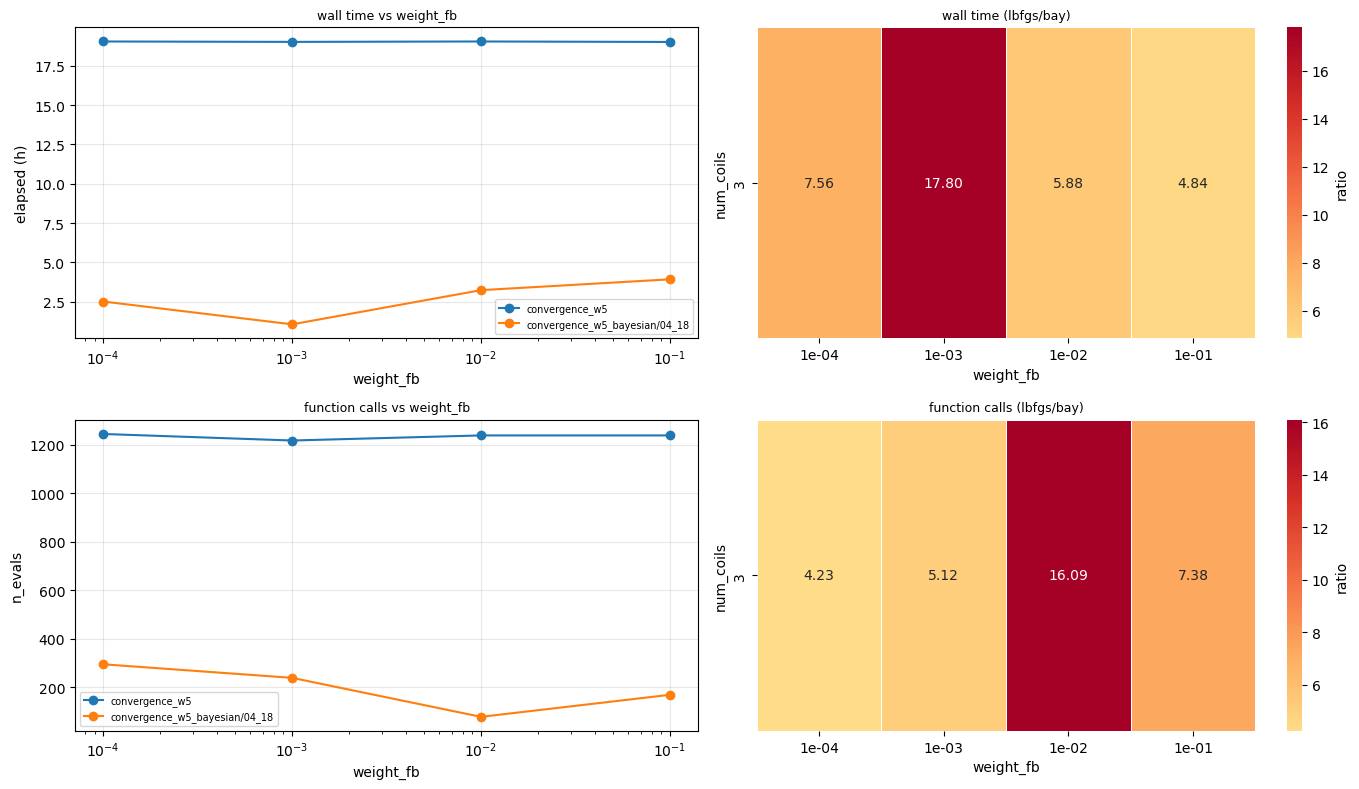

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for sweep in df['sweep'].unique():
    sub = df[df['sweep'] == sweep].sort_values('weight_fb')
    axes[0][0].plot(sub['weight_fb'], sub['elapsed_h'], marker='o', label=sweep)
    axes[1][0].plot(sub['weight_fb'], sub['n_evals'], marker='o', label=sweep)

for ax, ylabel, title in [
    (axes[0][0], 'elapsed (h)', 'wall time vs weight_fb'),
    (axes[1][0], 'n_evals', 'function calls vs weight_fb'),
]:
    ax.set_xscale('log')
    ax.set_xlabel('weight_fb')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for ratio_data, ax, title in [
    (lbf[['elapsed_h']] / bay[['elapsed_h']], axes[0][1], 'wall time (lbfgs/bay)'),
    (lbf[['n_evals']] / bay[['n_evals']], axes[1][1], 'function calls (lbfgs/bay)'),
]:
    col = ratio_data.columns[0]
    pivot = ratio_data.reset_index().pivot(index='num_coils', columns='weight_fb', values=col)
    pivot.columns = [f'{w:.0e}' for w in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', center=1.0, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'ratio'})
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('weight_fb')
    ax.set_ylabel('num_coils')

plt.tight_layout()
plt.show()

 

In [11]:
lbfgs_runs = [r for r in runs if r['method'] != 'Bayesian']

all_drops = {w: [] for w in sorted(set(r['weight_fb'] for r in lbfgs_runs))}
summary_rows = []

for r in lbfgs_runs:
    d = r['data']
    cost = np.array(d['cost_history'], dtype=float)
    boundaries = [0] + list(d['start_boundaries'])

    for i in range(len(boundaries) - 1):
        seg = cost[boundaries[i]:boundaries[i+1]]
        if len(seg) < 2:
            continue
        drops = -np.diff(seg)
        summary_rows.append({
            'weight_fb': r['weight_fb'],
            'start': i + 1,
            'n_evals': len(seg),
            'start_cost': seg[0],
            'best_drop': float(seg[0] - np.nanmin(seg)),
            'median_step_drop': float(np.median(np.abs(drops))),
            'p90_step_drop': float(np.percentile(np.abs(drops), 90)),
            'pct_improving': float(np.mean(drops > 0) * 100),
        })
        all_drops[r['weight_fb']].extend(drops.tolist())

ds = pd.DataFrame(summary_rows)
pd.set_option('display.float_format', '{:.3e}'.format)
print(ds.to_string(index=False))


 weight_fb  start  n_evals  start_cost  best_drop  median_step_drop  p90_step_drop  pct_improving
 1.000e-01      1      567   1.004e+00  3.363e-01         7.115e-08      6.810e-07      5.230e+01
 1.000e-01      2      147   1.464e+00  6.347e-09         2.379e-09      2.478e-08      4.795e+01
 1.000e-01      3      280   1.125e+01  9.752e+00         2.805e-09      2.230e-03      5.125e+01
 1.000e-02      1      679   1.004e+00  8.721e-01         9.728e-07      2.098e-04      4.882e+01
 1.000e-02      2      294   8.520e-01  1.410e-01         8.379e-09      1.198e-07      4.744e+01
 1.000e-03      1      259   1.004e+00  6.589e-01         1.128e-07      1.776e-06      5.504e+01
 1.000e-03      2      210   6.926e-01  4.154e-07         1.676e-09      3.744e-08      4.641e+01
 1.000e-03      3      112   3.533e+00  2.333e+00         2.172e-09      4.307e-06      5.315e+01
 1.000e-03      4      217   3.897e-01  5.929e-02         3.961e-08      3.987e-04      4.722e+01
 1.000e-03      5   

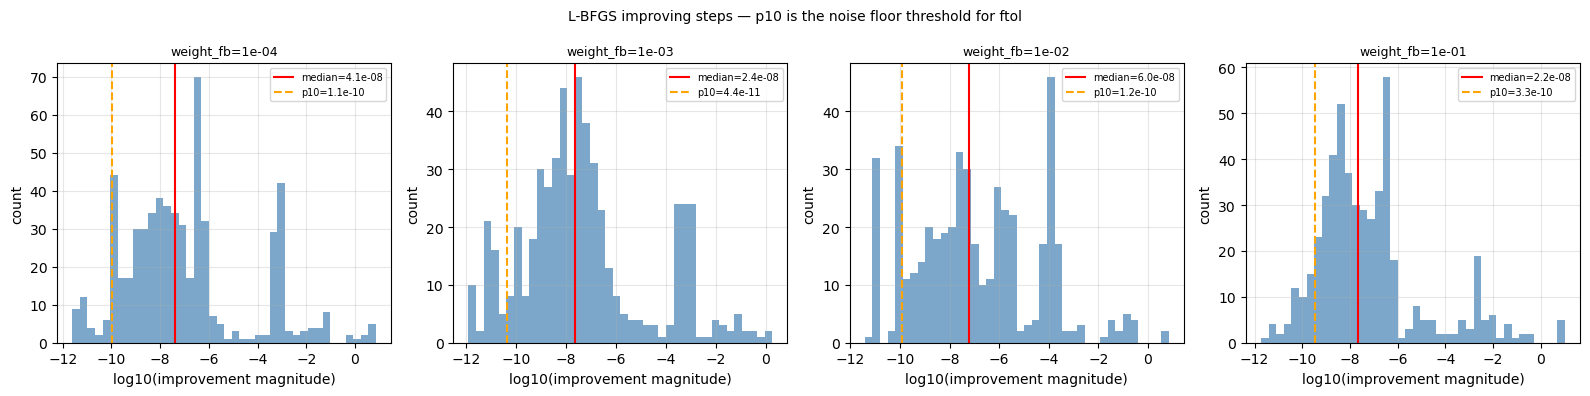

In [12]:
fig, axes = plt.subplots(1, len(all_drops), figsize=(4 * len(all_drops), 4), sharey=False)
for ax, (w, drops) in zip(axes, sorted(all_drops.items())):
    drops = np.array(drops)
    improving = drops[drops > 0]
    if len(improving):
        ax.hist(np.log10(improving), bins=40, color='steelblue', alpha=0.7)
        ax.axvline(np.log10(np.median(improving)), color='red', lw=1.5, label=f'median={np.median(improving):.1e}')
        ax.axvline(np.log10(np.percentile(improving, 10)), color='orange', lw=1.5, ls='--', label=f'p10={np.percentile(improving, 10):.1e}')
    ax.set_title(f'weight_fb={w:.0e}', fontsize=9)
    ax.set_xlabel('log10(improvement magnitude)')
    ax.set_ylabel('count')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('L-BFGS improving steps — p10 is the noise floor threshold for ftol', fontsize=10)
plt.tight_layout()
plt.show()

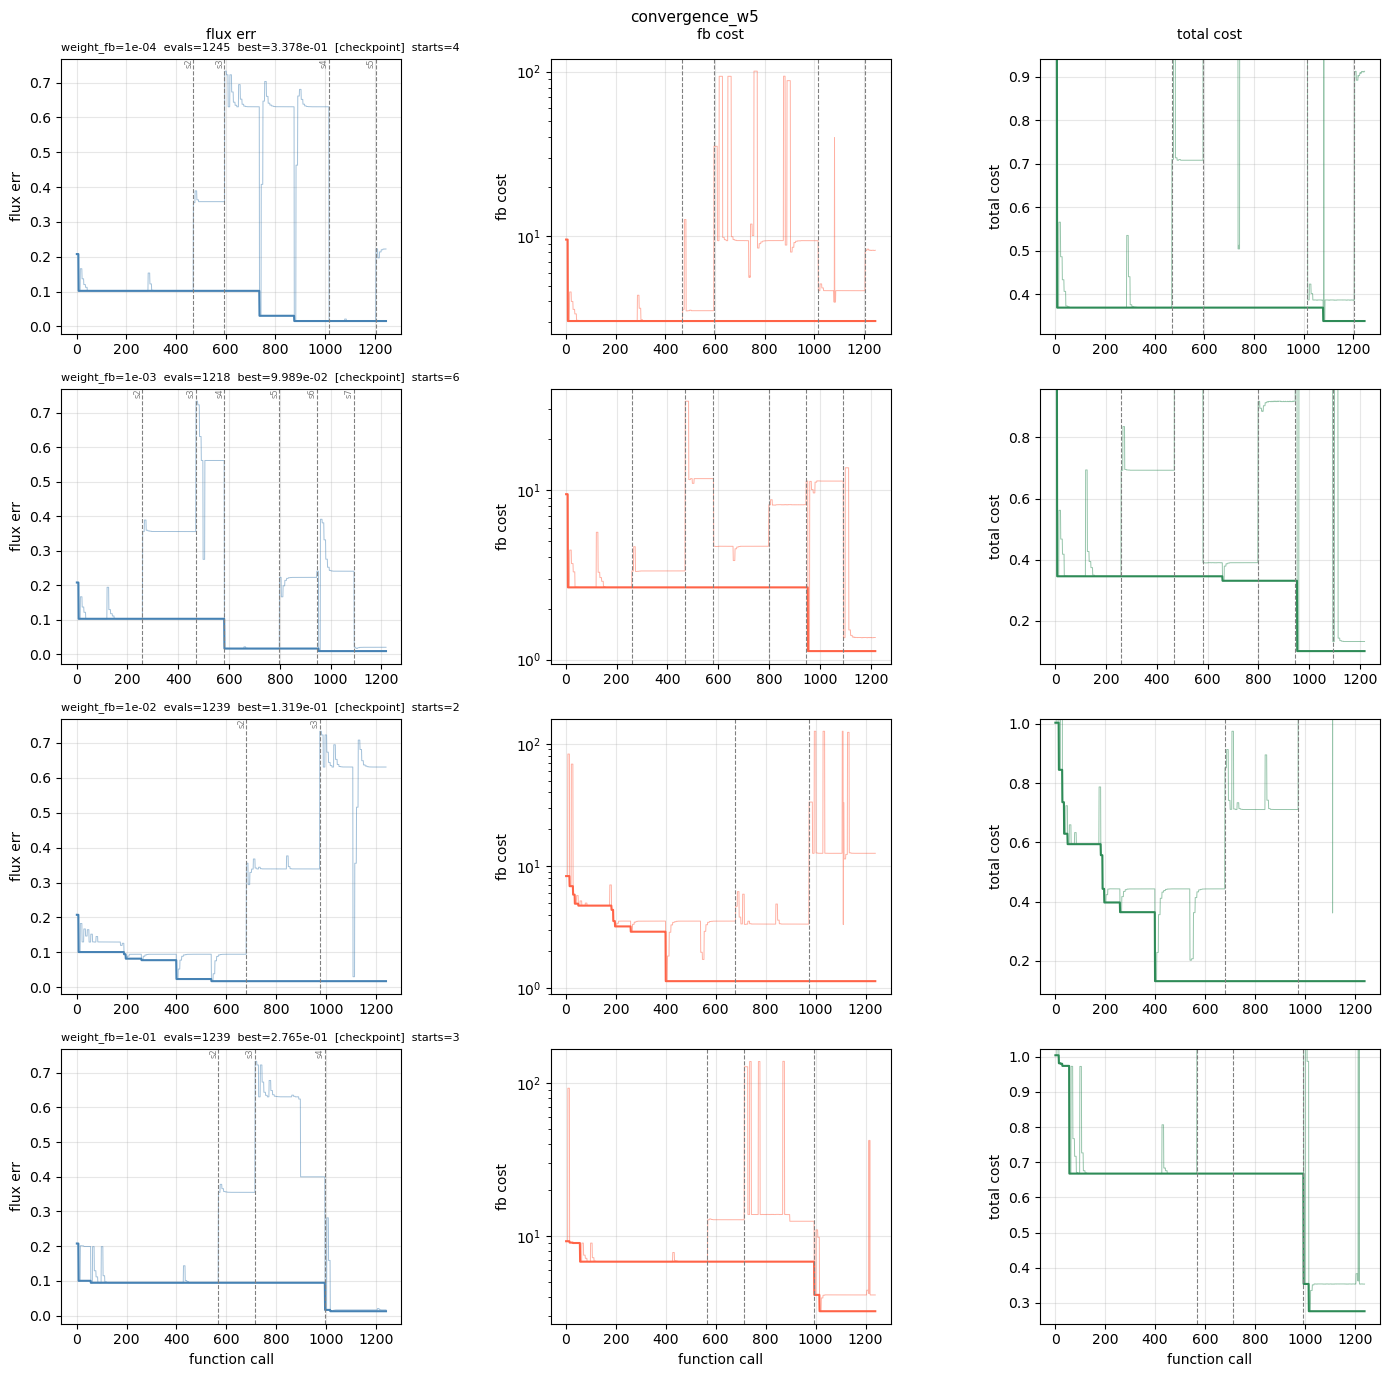

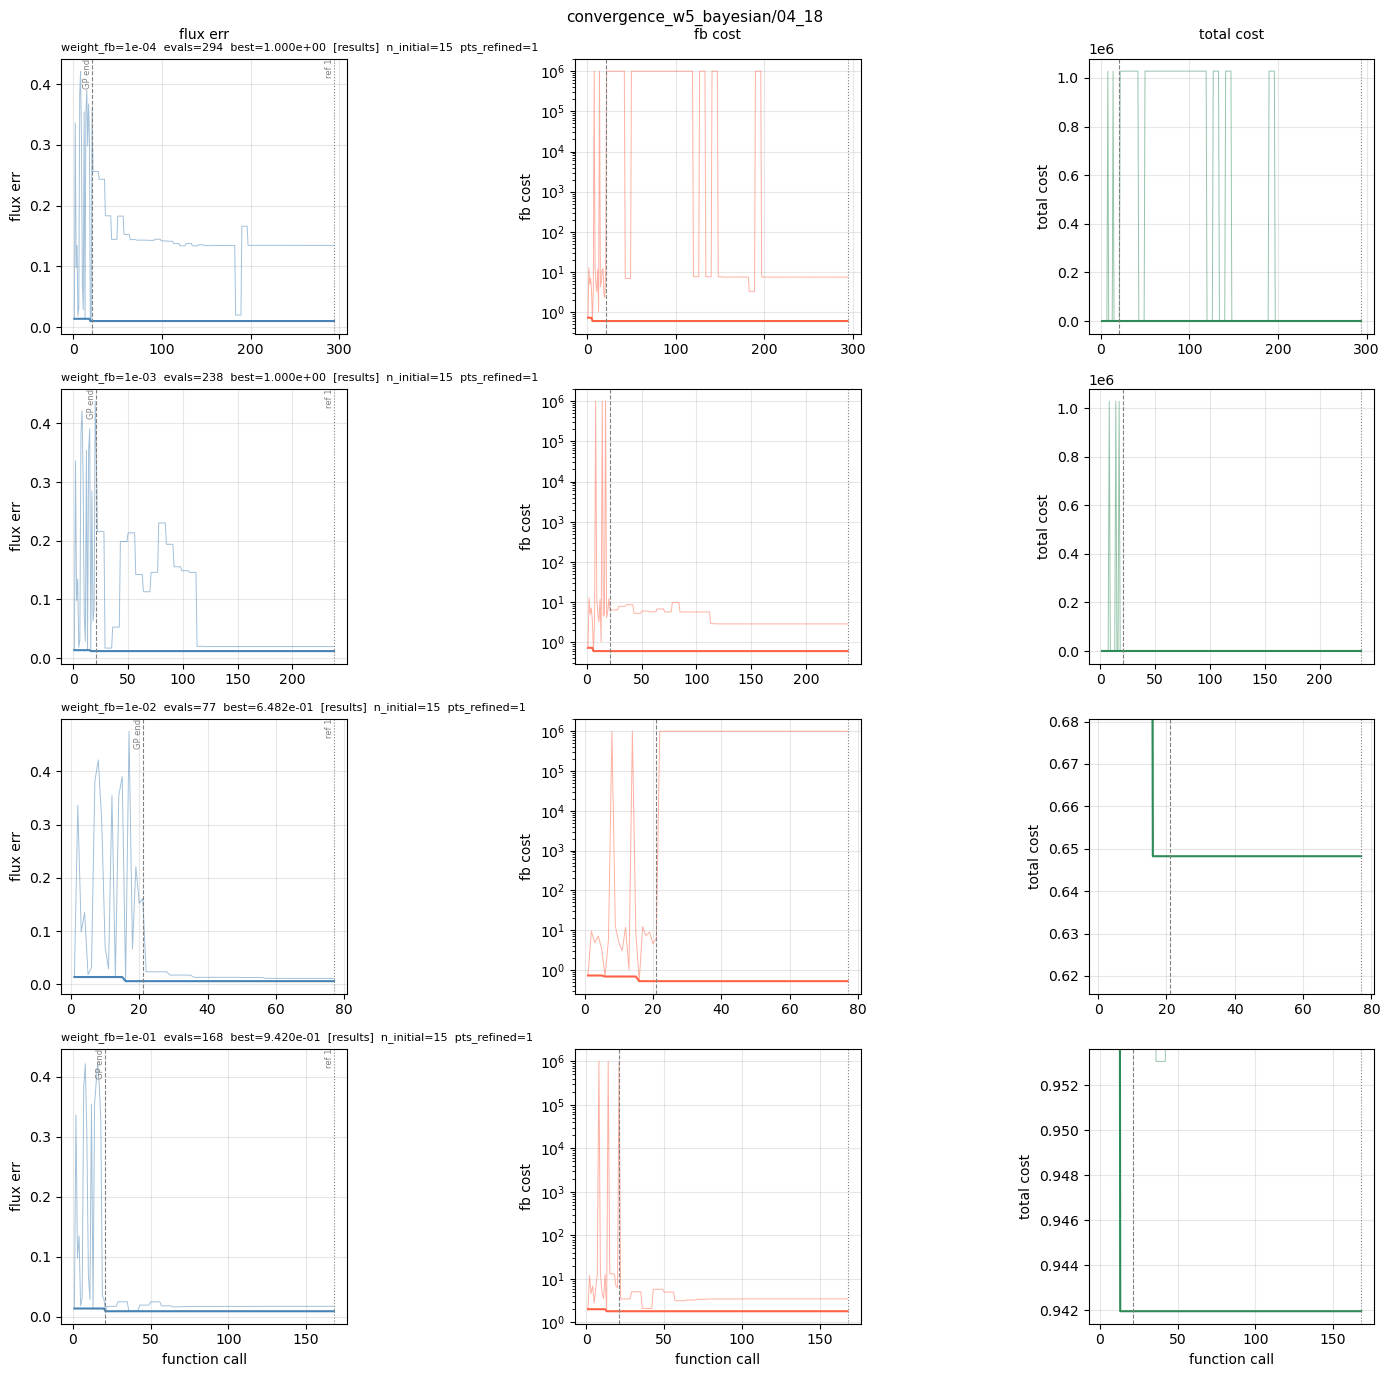

In [ ]:
# --- filter ---
SHOW_SWEEPS = None   # None = all, or e.g. ['convergence_w5']
SHOW_WEIGHTS = None  # None = all, or e.g. [1e-2, 1e-4]
SHOW_COILS = None    # None = all, or e.g. [3, 4]
CLIP = 1          # values >= this are plotted but ignored for ylim
# --------------

filtered = [
    r for r in runs
    if (SHOW_SWEEPS is None or r['sweep'] in SHOW_SWEEPS)
    and (SHOW_WEIGHTS is None or any(abs(r['weight_fb'] - w) < 1e-12 for w in SHOW_WEIGHTS))
    and (SHOW_COILS is None or r['num_coils'] in SHOW_COILS)
]

COL_LABELS = ['flux err', 'fb cost', 'total cost']

for sweep in sorted(set(r['sweep'] for r in filtered)):
    sweep_runs = [r for r in filtered if r['sweep'] == sweep]
    n = len(sweep_runs)
    fig, axes = plt.subplots(n, 3, figsize=(14, 3.5 * n), sharex=False, squeeze=False)
    fig.suptitle(sweep, fontsize=11)

    for col, label in enumerate(COL_LABELS):
        axes[0][col].set_title(label, fontsize=10, pad=14)

    for row, r in enumerate(sorted(sweep_runs, key=lambda x: x['weight_fb'])):
        d = r['data']
        total = np.array(d['cost_history'], dtype=float)
        flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
        fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

        phase_lines = []  # (label, x, linestyle)

        if r['method'] == 'Bayesian':
            n_bay = d.get('n_bayesian_evals', 0)
            ref_evals = d.get('refinement_evals', [])
            k = len(ref_evals) if K_REFINED is None else min(K_REFINED, len(ref_evals))
            trunc = n_bay + sum(ref_evals[:k])
            total, flux, fb = total[:trunc], flux[:trunc], fb[:trunc]
            phase_lines.append(('GP end', n_bay, '--'))
            cumulative = n_bay
            for i, re in enumerate(ref_evals[:k]):
                cumulative += re
                phase_lines.append((f'ref {i+1}', cumulative, ':'))
            pts_label = k if K_REFINED is not None else d.get('pts_refined', '?')
            extra = f"  n_initial={d.get('n_initial','?')}  pts_refined={pts_label}"
        else:
            for i, x in enumerate(d.get('start_boundaries', [])):
                phase_lines.append((f's{i+2}', x, '--'))
            extra = f"  starts={d.get('starts_completed','?')}"

        evals = np.arange(1, len(total) + 1)
        run_title = f"weight_fb={r['weight_fb']:.0e}  evals={len(total)}  best={np.nanmin(total):.3e}  [{r['source']}]{extra}"

        for ax, y, color, ylabel in zip(
            axes[row],
            [flux, fb, total],
            ['steelblue', 'tomato', 'seagreen'],
            COL_LABELS,
        ):
            ax.plot(evals, y, lw=0.7, alpha=0.5, color=color)
            running_best = np.minimum.accumulate(np.where(np.isnan(y), np.inf, y))
            running_best[running_best == np.inf] = np.nan
            ax.plot(evals, running_best, lw=1.5, color=color)
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            if row == len(sweep_runs) - 1:
                ax.set_xlabel('function call')

            if ylabel == "fb cost":
                ax.set_yscale("log")
            else:
                finite = y[np.isfinite(y) & (y < CLIP)]
                if len(finite):
                    pad = (finite.max() - finite.min()) * 0.05 or finite.min() * 0.05
                    ax.set_ylim(finite.min() - pad, finite.max() + pad)

            for lbl, x, ls in phase_lines:
                ax.axvline(x, color='gray', lw=0.8, ls=ls)
                if ax is axes[row][0]:
                    ax.text(x, ax.get_ylim()[1], lbl, fontsize=6, ha='right',
                            va='top', rotation=90, color='gray')

        axes[row][0].annotate(run_title, xy=(0, 1), xycoords='axes fraction',
                              xytext=(0, 4), textcoords='offset points',
                              fontsize=8, va='bottom')

    plt.tight_layout()
    plt.show()

In [14]:
# omega analysis: coil separation and penalty fraction across all lbfgs runs
import itertools

SWEEPS_OMEGA = [LBFGS_SWEEP, 'convergence_w5_lbfgs/04_18']

omega_rows = []
for sweep in SWEEPS_OMEGA:
    sweep_dir = os.path.join(BASE, sweep)
    if not os.path.isdir(sweep_dir):
        continue
    for config in sorted(os.listdir(sweep_dir)):
        config_dir = os.path.join(sweep_dir, config)
        if not os.path.isdir(config_dir):
            continue
        for run in sorted(os.listdir(config_dir)):
            rpath = os.path.join(config_dir, run, 'results.json')
            if not os.path.exists(rpath):
                rpath = os.path.join(config_dir, run, 'checkpoint.json')
            if not os.path.exists(rpath):
                continue
            d = json.load(open(rpath))
            s = d.get('optimization_settings', {})
            omega = s.get('omega', float('nan'))
            dist_th = s.get('dist_th', 5.0)
            num_coils = s.get('num_coils', None)
            weight_fb = s.get('weight_fb', float('nan'))
            methods_data = d.get('methods', {})
            if not methods_data:
                methods_data = {'L-BFGS': d}
            for mname, m in methods_data.items():
                if 'Bayesian' in mname:
                    continue
                thetas = m.get('parameters', {}).get('thetas', [])
                if not thetas:
                    continue
                thetas_s = sorted(thetas)
                diffs = np.diff(thetas_s)
                violations = np.maximum(dist_th - diffs, 0.0)
                penalty = omega * np.sum(violations ** 2)
                best_cost = m.get('best_cost', float('nan'))
                pen_frac = penalty / best_cost if best_cost > 0 else float('nan')
                omega_rows.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'num_coils': num_coils,
                    'weight_fb': weight_fb,
                    'omega': omega,
                    'dist_th': dist_th,
                    'min_sep': diffs.min() if len(diffs) else float('nan'),
                    'n_violations': int(np.sum(violations > 0)),
                    'penalty': penalty,
                    'best_cost': best_cost,
                    'pen_frac': pen_frac,
                })

odf = pd.DataFrame(omega_rows)
print(odf[['config','num_coils','weight_fb','omega','min_sep','n_violations','penalty','best_cost','pen_frac']].to_string(index=False))

                                      config  num_coils  weight_fb     omega   min_sep  n_violations   penalty  best_cost  pen_frac
alpha:0.75,weight:1e-01,lambda:1e-06,coils:3          3  1.000e-01 1.000e-03 1.387e+01             0 0.000e+00  2.765e-01 0.000e+00
alpha:0.75,weight:1e-02,lambda:1e-06,coils:3          3  1.000e-02 1.000e-03 1.387e+01             0 0.000e+00  1.319e-01 0.000e+00
alpha:0.75,weight:1e-03,lambda:1e-06,coils:3          3  1.000e-03 1.000e-03 3.777e+01             0 0.000e+00  9.989e-02 0.000e+00
alpha:0.75,weight:1e-04,lambda:1e-06,coils:3          3  1.000e-04 1.000e-03 2.826e+01             0 0.000e+00  3.378e-01 0.000e+00
alpha:0.75,weight:1e-01,lambda:1e-06,coils:3          3  1.000e-01 1.000e-03 3.762e+01             0 0.000e+00  1.895e-01 0.000e+00
alpha:0.75,weight:1e-02,lambda:1e-06,coils:3          3  1.000e-02 1.000e-03 3.777e+01             0 0.000e+00  1.196e-01 0.000e+00
alpha:0.75,weight:1e-03,lambda:1e-06,coils:3          3  1.000e-03 1.000e-03

In [15]:
# what omega is needed to make penalty = TARGET_FRAC * cost when coils just touch (sep=0)
# penalty_at_zero = omega * num_pairs * dist_th^2
# => omega_needed = TARGET_FRAC * cost / (num_pairs * dist_th^2)

TARGET_FRACS = [0.1, 0.25, 0.5]

print('dist_th assumed = 5.0 deg')
print('worst case: all pairs stacked (sep=0 for all pairs)')
print()

for nc in sorted(odf['num_coils'].dropna().unique()):
    nc = int(nc)
    n_pairs = nc * (nc - 1) // 2
    sub = odf[odf['num_coils'] == nc]
    median_cost = sub['best_cost'].median()
    print(f'num_coils={nc}  n_pairs={n_pairs}  median_cost={median_cost:.4e}')
    for frac in TARGET_FRACS:
        omega_needed = frac * median_cost / (n_pairs * 5.0**2)
        print(f'  pen={int(frac*100)}% of cost => omega ~ {omega_needed:.2e}')
    print()

print('--- for current omega=1e-3, sep at which single-pair penalty = X% of median cost ---')
for nc in sorted(odf['num_coils'].dropna().unique()):
    nc = int(nc)
    sub = odf[odf['num_coils'] == nc]
    median_cost = sub['best_cost'].median()
    omega_cur = 1e-3
    for frac in [0.1, 0.25]:
        gap = (frac * median_cost / omega_cur) ** 0.5
        sep_trigger = 5.0 - gap
        print(f'  nc={nc} pen={int(frac*100)}%: sep must be < {sep_trigger:.2f} deg (need {gap:.2f} deg inside threshold)')

dist_th assumed = 5.0 deg
worst case: all pairs stacked (sep=0 for all pairs)

num_coils=3  n_pairs=3  median_cost=1.3152e-01
  pen=10% of cost => omega ~ 1.75e-04
  pen=25% of cost => omega ~ 4.38e-04
  pen=50% of cost => omega ~ 8.77e-04

--- for current omega=1e-3, sep at which single-pair penalty = X% of median cost ---
  nc=3 pen=10%: sep must be < 1.37 deg (need 3.63 deg inside threshold)
  nc=3 pen=25%: sep must be < -0.73 deg (need 5.73 deg inside threshold)


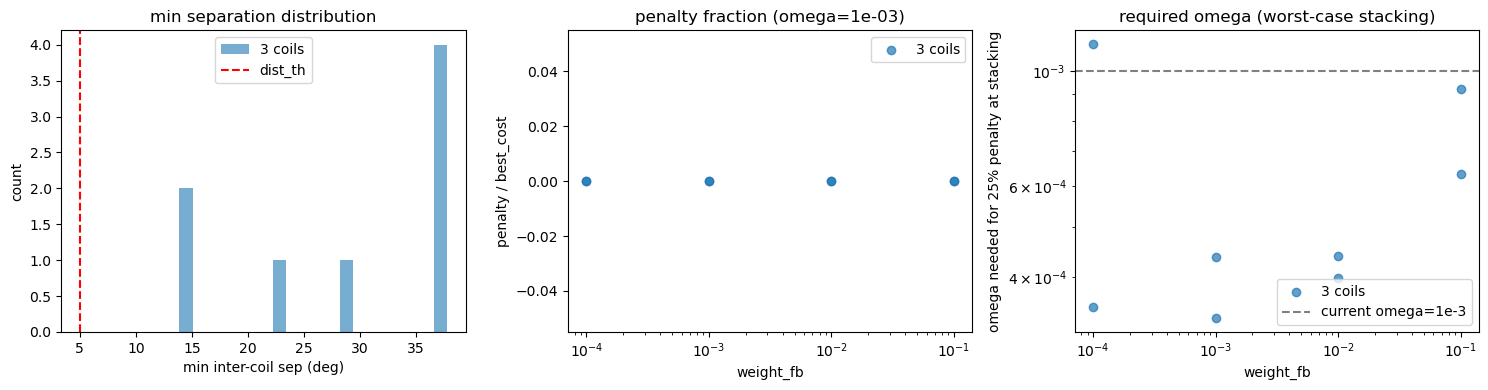

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for nc, grp in odf.groupby('num_coils'):
    axes[0].hist(grp['min_sep'].dropna(), bins=20, alpha=0.6, label=f'{int(nc)} coils')
axes[0].axvline(x=float(odf['dist_th'].iloc[0]), color='r', linestyle='--', label='dist_th')
axes[0].set_xlabel('min inter-coil sep (deg)')
axes[0].set_ylabel('count')
axes[0].set_title('min separation distribution')
axes[0].legend()

for nc, grp in odf.groupby('num_coils'):
    axes[1].scatter(grp['weight_fb'], grp['pen_frac'], label=f'{int(nc)} coils', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_xlabel('weight_fb')
axes[1].set_ylabel('penalty / best_cost')
axes[1].set_title(f'penalty fraction (omega={float(odf["omega"].iloc[0]):.0e})')
axes[1].legend()

TARGET = 0.25
for nc, grp in odf.groupby('num_coils'):
    nc = int(nc)
    n_pairs = nc * (nc - 1) // 2
    omega_req = TARGET * grp['best_cost'] / (n_pairs * grp['dist_th']**2)
    axes[2].scatter(grp['weight_fb'], omega_req, label=f'{nc} coils', alpha=0.7)
axes[2].axhline(y=1e-3, color='gray', linestyle='--', label='current omega=1e-3')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('weight_fb')
axes[2].set_ylabel('omega needed for 25% penalty at stacking')
axes[2].set_title('required omega (worst-case stacking)')
axes[2].legend()

plt.tight_layout()
plt.show()